<a href="https://colab.research.google.com/github/carolsabara/Telecom_X/blob/main/TelecomX_1Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import math


In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

Nessa etapa preciso verificar quem são os resultados nulos, os brancos/vazios, valores únicos e os duplicados

In [5]:
for col in df.columns:
  print(col, ":", df[col].nunique())
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

customerID : 7267
Churn : 3
['No' 'Yes' '']
--------------------------------------------------
customer.gender : 2
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen : 2
[0 1]
--------------------------------------------------
customer.Partner : 2
['Yes' 'No']
--------------------------------------------------
customer.Dependents : 2
['Yes' 'No']
--------------------------------------------------
customer.tenure : 73
phone.PhoneService : 2
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines : 3
['No' 'Yes' 'No phone service']
--------------------------------------------------
internet.InternetService : 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
internet.OnlineSecurity : 3
['No' 'Yes' 'No internet service']
--------------------------------------------------
internet.OnlineBackup : 3
['Yes' 'No' 'No internet service']
--------------------------------------------------
internet.De

In [6]:
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


In [7]:
print("Numero de nulos", df.isnull().sum())

Numero de nulos customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [8]:
df.select_dtypes(include="object").apply(
    lambda x: x.isna().sum() + x.str.strip().eq("").sum()
)


,0
customerID,0
Churn,224
customer.gender,0
customer.Partner,0
customer.Dependents,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0
internet.OnlineSecurity,0
internet.OnlineBackup,0


In [9]:
df["Churn"] = df["Churn"].str.strip()
df["Churn"] = df["Churn"].replace("", np.nan)

In [10]:

df = df.dropna(subset = ['Churn'])

In [11]:
df = df.dropna(subset=["Churn"]).copy()

In [12]:
#para colunas -> rename
colunas = {
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem_60mais',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem_60mais,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [13]:
df['total_cobrado'] = pd.to_numeric(df['total_cobrado'], errors = 'coerce')
df['total_cobrado'].dtype

dtype('float64')

In [14]:
df = df.dropna(subset =['total_cobrado'])


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7032 non-null   object 
 1   Churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   tem_60mais            7032 non-null   int64  
 4   possui_parceiro       7032 non-null   object 
 5   possui_dependentes    7032 non-null   object 
 6   tempo_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   tipo_internet         7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes      7032

In [16]:
df['total_cobrado'].isnull().sum()

np.int64(0)

In [17]:
df.isnull().sum()

,0
id,0
Churn,0
genero,0
tem_60mais,0
possui_parceiro,0
possui_dependentes,0
tempo_contrato,0
servico_telefone,0
multiplas_linhas,0
tipo_internet,0


In [18]:
#para conteúdo no dataset -> replace
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df.head()

/tmp/ipython-input-4130251336.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
/tmp/ipython-input-4130251336.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
/tmp/ipython-input-4130251336.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

,id,Churn,genero,tem_60mais,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [19]:
colunas_Translate = [
'seguranca_online',
'backup_online',
'protecao_dispositivo',
'suporte_tecnico',
'streaming_tv',
'streaming_filmes',
'fatura_digital',
'multiplas_linhas'
                      ]

nomes_atualizados = {'Yes':'Sim', 'No':'Não', 'No internet service': 'Sem serviço de internet', 'No phone service': 'Sem serviço de telefone'}

for col in colunas_Translate:
  df[col] = df[col].replace(nomes_atualizados)

/tmp/ipython-input-1528094901.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].replace(nomes_atualizados)


In [20]:
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})

/tmp/ipython-input-2071926769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})


In [45]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de créd. (automático)',
    'Bank transfer (automatic)': 'Transferência Banc. (automática)'
})

df.head()

/tmp/ipython-input-579147759.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,id,Churn,genero,tem_60mais,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias,Churn_binaria,faixa_valor
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667,0,Médio
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667,0,Médio
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333,1,Médio
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667,1,Alto
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667,1,Médio


##Coluna de contas diárias


In [23]:
df['contas_diarias'] = df['valor_mensal'] / 30
df.head()

/tmp/ipython-input-1698306105.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['contas_diarias'] = df['valor_mensal'] / 30


,id,Churn,genero,tem_60mais,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


#📊 Carga e análise

In [24]:
df.describe()

,tem_60mais,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


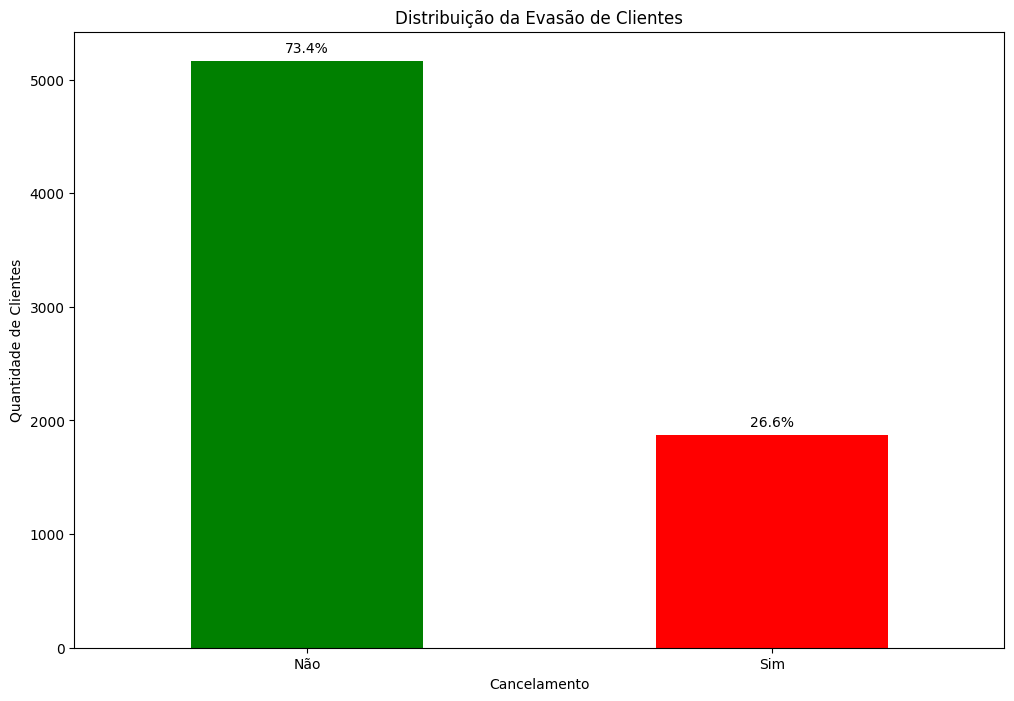

In [25]:
plt.figure(figsize=(12, 8))
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar', color = ['green', 'red'])
plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)
for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va ='bottom')

plt.show()

In [26]:
df["Churn_binaria"] = df["Churn"].replace({"Sim": 1, "Não": 0})


/tmp/ipython-input-4062167969.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn_binaria"] = df["Churn"].replace({"Sim": 1, "Não": 0})
/tmp/ipython-input-4062167969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Churn_binaria"] = df["Churn"].replace({"Sim": 1, "Não": 0})


###Geralmente as váriaveis que mais influenciam o Churn são


*  Tipo de Contrato
*  Tempo de contrato
*  Valor mensal
*  Método de pagamento


Portanto essas analisa-las uma por uma

##Qual tipo de contrato apresenta uma taxa de cancelamento maior?


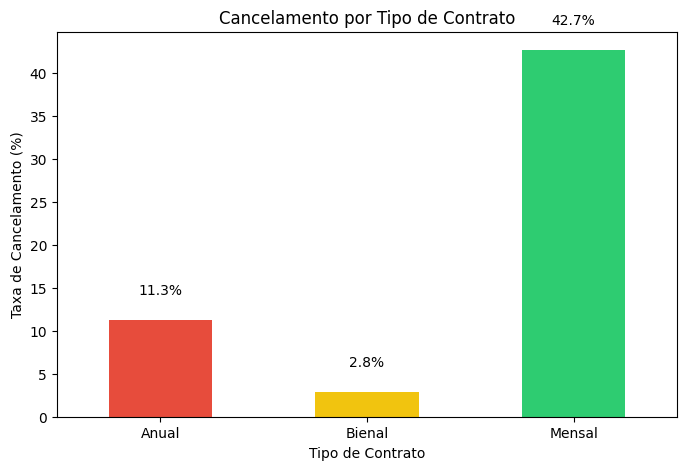

In [28]:
churn_contrato = df.groupby("tipo_contrato")["Churn_binaria"].mean() * 100

plt.figure(figsize=(8,5))

ax = churn_contrato.plot(
    kind="bar",
    color=["#e74c3c", "#f1c40f", "#2ecc71"]
)

plt.title("Cancelamento por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Taxa de Cancelamento (%)")
plt.xticks(rotation=0)

for i, v in enumerate(churn_contrato.values):
    ax.text(i, v + 3, f"{v:.1f}%", ha="center") # Adjusted 'v + 1' to 'v + 3'

plt.show()

In [29]:
df.groupby('Churn_binaria')['tempo_contrato'].mean()

,tempo_contrato
Churn_binaria,
0,37.650010
1,17.979133


##Clientes que cancelam mais têm tempo de contrato mais curto?

/tmp/ipython-input-183531454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


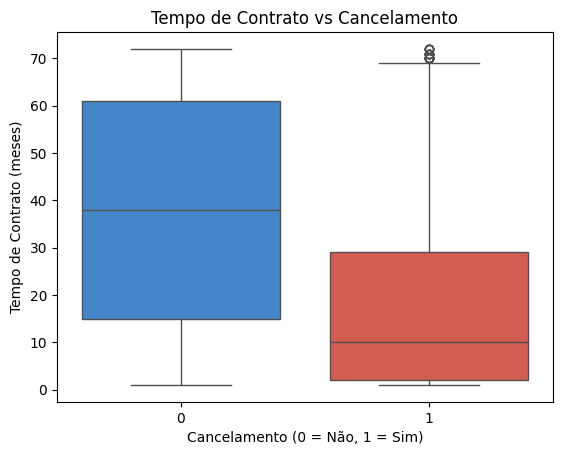

In [30]:
cancelamento_por_contrato = df.groupby('Churn_binaria')['tempo_contrato'].mean()

sns.boxplot(
    x="Churn_binaria",
    y="tempo_contrato",
    data=df,
    palette=["#2E86DE", "#E74C3C"]
)

plt.title("Tempo de Contrato vs Cancelamento")
plt.xlabel("Cancelamento (0 = Não, 1 = Sim)")
plt.ylabel("Tempo de Contrato (meses)")

plt.show()

### Os gráficos revelam que o Churn está concentrado em clientes com pouco tempo de contrato. Os motivos devem ser investigados.

#Clientes que cancelam pagam mais ?

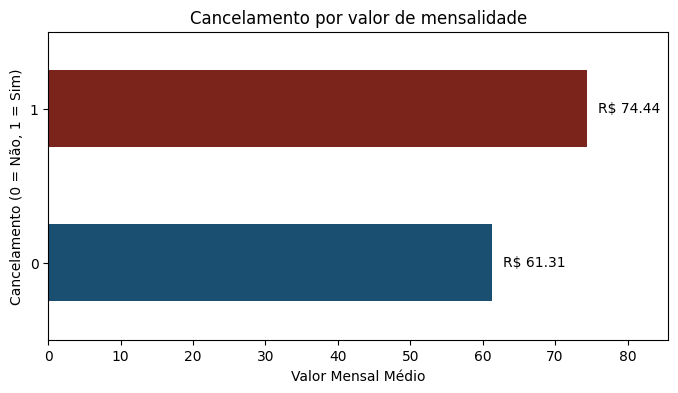

In [31]:
churn_do_valor_mensal = df.groupby('Churn_binaria')['valor_mensal'].mean().sort_values()
plt.figure(figsize=(8,4))
ax= churn_do_valor_mensal.plot(
    kind = 'barh',
    color = ["#1B4F72", "#7B241C"]

)
ax.set_xlim(0, churn_do_valor_mensal.max() * 1.15)
plt.xticks(rotation=0)
plt.title('Cancelamento por valor de mensalidade')
plt.ylabel('Cancelamento (0 = Não, 1 = Sim)')
plt.xlabel('Valor Mensal Médio')
for i, v in enumerate(churn_do_valor_mensal.values):
    ax.text(v + churn_do_valor_mensal.max()*0.02, i, f"R$ {v:.2f}",
            va="center", ha="left")

plt.show()

##Insight: Clientes que pagam mais tendem a cancelar mais.


# Qual o método de pagamento dos clientes que mais cancelam ?

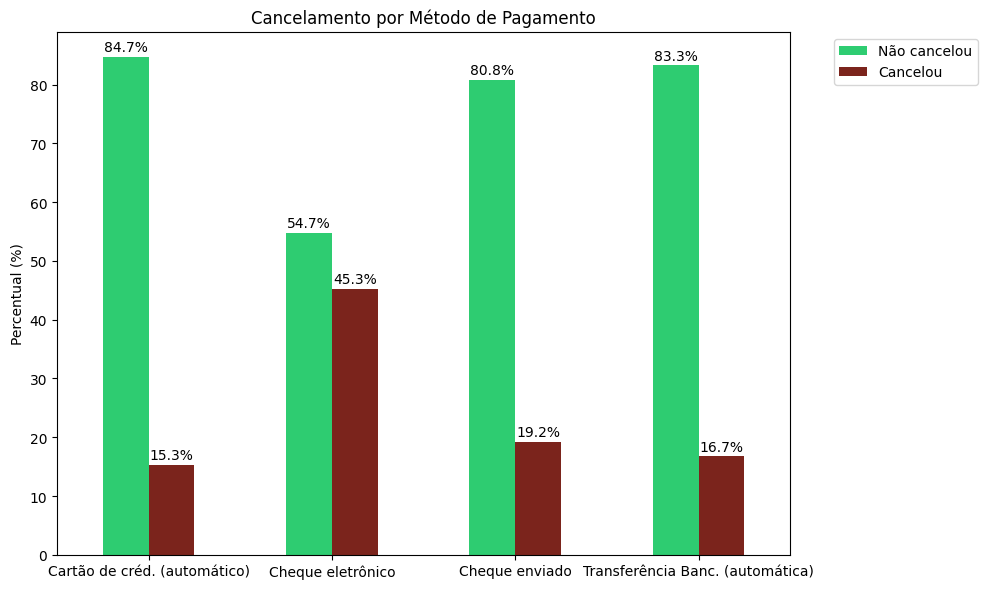

In [44]:
import pandas as pd
tabela = pd.crosstab(
    df["metodo_pagamento"],
    df["Churn_binaria"],
    normalize="index"
) * 100

tabela.columns = ["Não cancelou", "Cancelou"]

ax = tabela.plot(
    kind="bar",
    color=["#2ecc71", "#7B241C"],
    figsize=(10,6)
)

plt.title("Cancelamento por Método de Pagamento")
plt.ylabel("Percentual (%)")
plt.xlabel("")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=0) # Reverted rotation to 0 as requested

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2)
plt.tight_layout()

plt.show()

## Insight: clientes com método de pag que n são automáticos cancelam mais

In [33]:
px.histogram(df, x = 'tempo_contrato', text_auto = True, color = 'Churn_binaria', barmode = 'group')

### Insight: Alta taxa de cancelamento nos primeiros meses e cai gradativamente conforme o tempo vai passando.

#Vamos analisar outras váriaveis


In [34]:
variaveis_categoricas = ['genero', 'tem_60mais', 'possui_parceiro',
       'possui_dependentes', 'servico_telefone', 'tipo_internet', 'fatura_digital',]

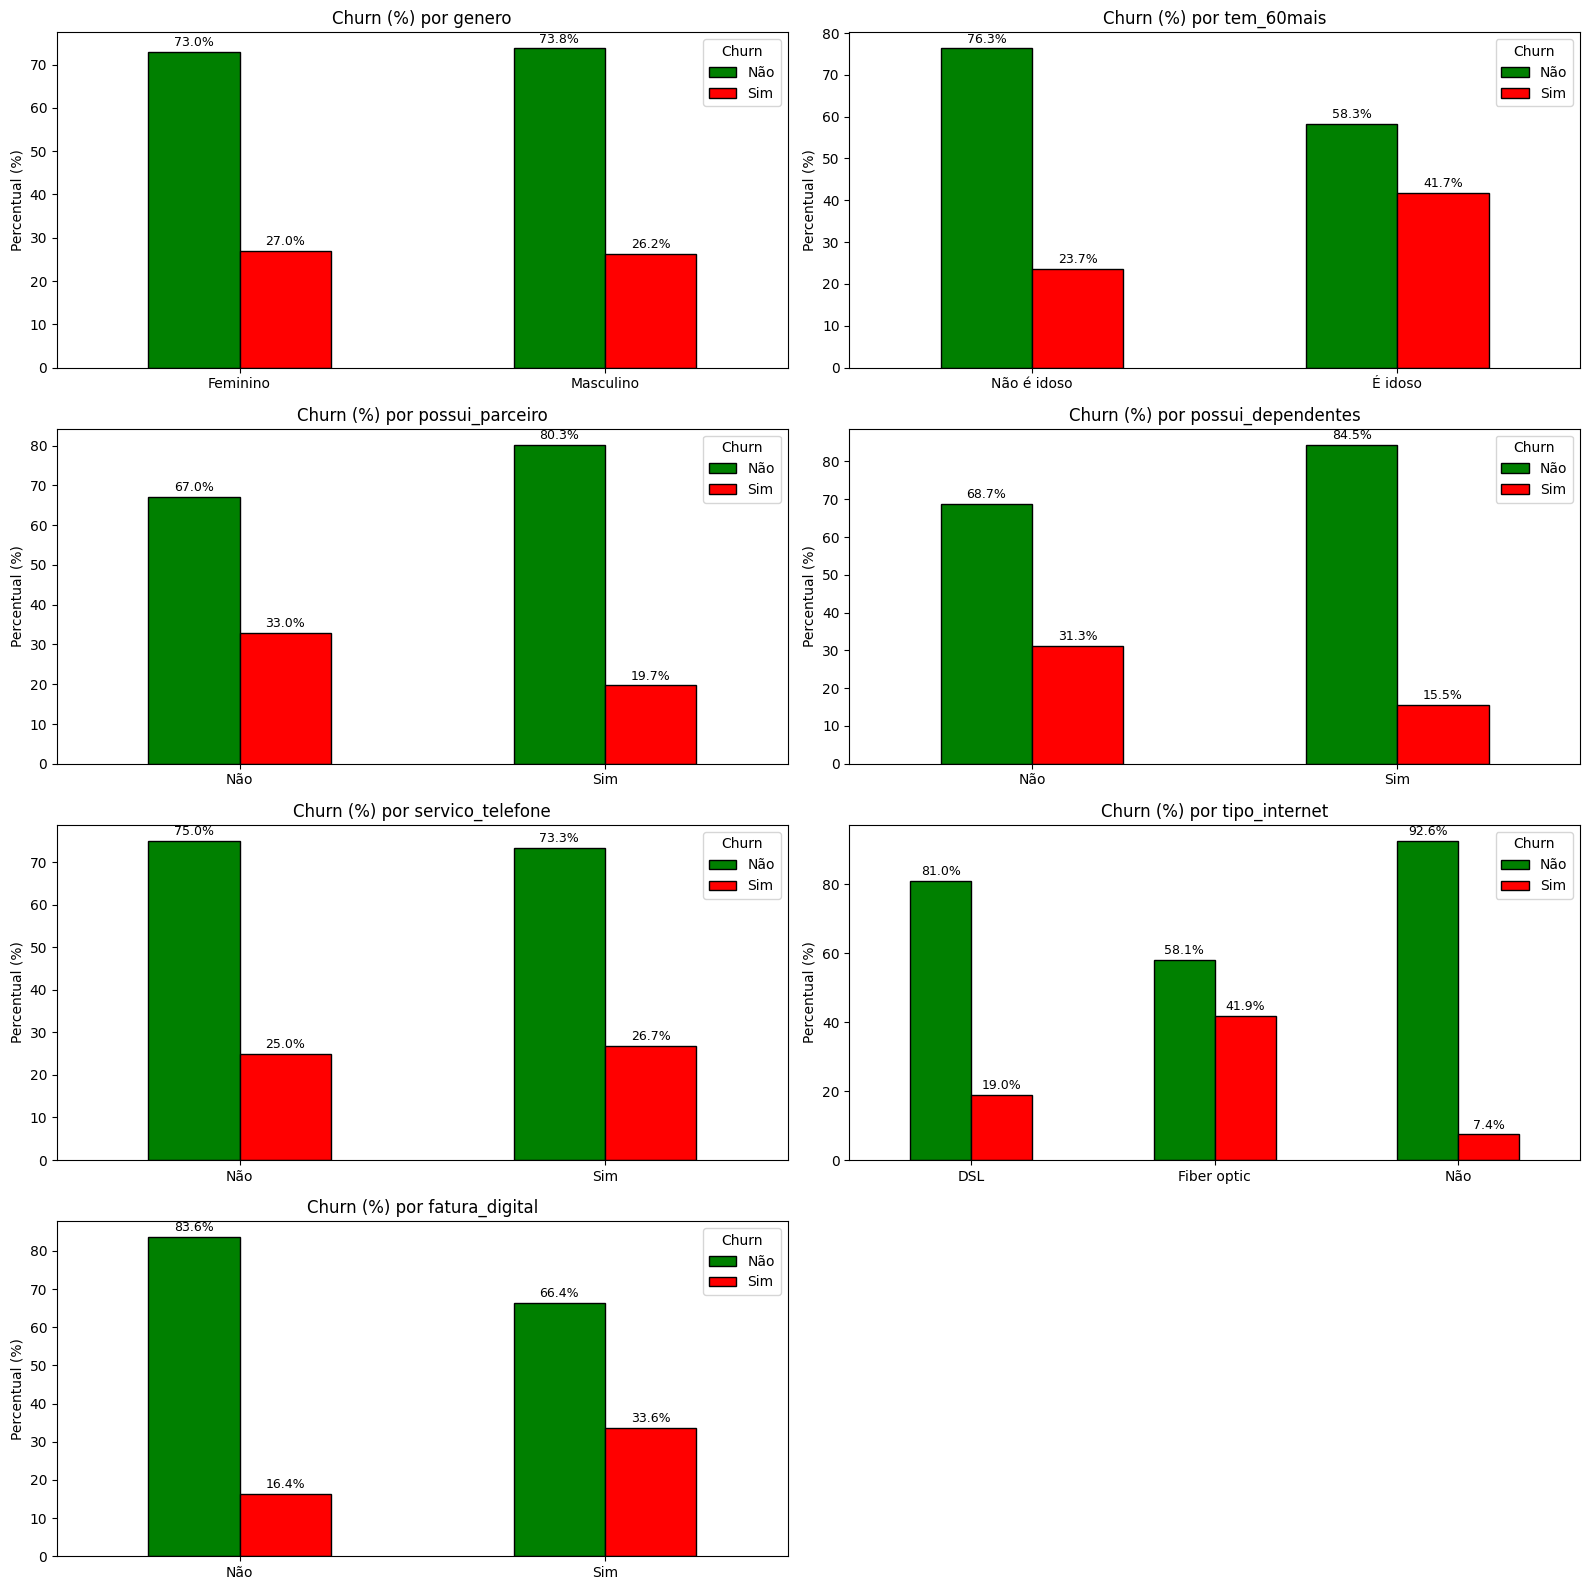

In [35]:
def plot_churn_por_categoricas(df, variaveis_categoricas, churn_col="Churn", n_cols=2):
    # garante ordem e existência das duas classes
    churn_order = ["Não", "Sim"]

    n = len(variaveis_categoricas)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(variaveis_categoricas):
        ax = axes[i]

        # tabela em porcentagem dentro de cada categoria
        tab = pd.crosstab(df[col], df[churn_col], normalize="index") * 100

        # garante que sempre tenha as duas colunas (Não e Sim), mesmo se uma sumir
        tab = tab.reindex(columns=churn_order, fill_value=0)

        # Aplica rótulos personalizados para 'tem_60mais'
        if col == 'tem_60mais':
            tab = tab.rename(index={0: 'Não é idoso', 1: 'É idoso'})

        # plota
        tab.plot(kind="bar", ax=ax, color=['green', 'red'], edgecolor="black")

        ax.set_title(f"Churn (%) por {col}", fontsize=12)
        ax.set_ylabel("Percentual (%)")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Churn", loc="upper right")

        # escreve % em cima das barras
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)

    # apaga subplots vazios
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    plt.show()

# USO:
plot_churn_por_categoricas(df, variaveis_categoricas, churn_col="Churn", n_cols=2)

#Qual perfil deve-se dar mais atenção?

In [36]:
perfil1 = df.groupby(['possui_parceiro', 'possui_dependentes'])['Churn_binaria'].mean() * 100
perfil1.sort_values(ascending = False)

,,Churn_binaria
possui_parceiro,possui_dependentes,
Não,Não,34.237805
Sim,Não,25.408348
Não,Sim,21.448468
Sim,Sim,14.310345


###→ 7,6 pontos percentuais acima da média geral do churn que é 26.6%
###→ 2,4x maior que o grupo mais estável.

###Deve-se se dar mais atenção a clientes sem vínculo familiar pois apresentam maior propensão ao cancelamento. E clientes com estrutura familiar tem menor chance de evasão.

#E sobre os clientes novos? Qual é o perfil que mais cancela?

In [37]:
df_recente = df[df['tempo_contrato']<= 12].sort_values(by='tempo_contrato')
print(df_recente)

              id Churn     genero  tem_60mais possui_parceiro  \
7187  9885-CSMWE   Sim   Feminino           1             Não   
88    0137-OCGAB   Sim   Feminino           0             Não   
65    0107-YHINA   Sim  Masculino           0             Não   
64    0107-WESLM   Sim  Masculino           0             Não   
49    0082-LDZUE   Não  Masculino           0             Não   
...          ...   ...        ...         ...             ...   
7152  9837-FWLCH   Não  Masculino           0             Sim   
86    0135-NMXAP   Sim   Feminino           0             Não   
7218  9928-BZVLZ   Não   Feminino           0             Não   
7131  9817-APLHW   Não  Masculino           0             Não   
124   0208-BPQEJ   Não   Feminino           0             Sim   

     possui_dependentes  tempo_contrato servico_telefone  \
7187                Não               1              Sim   
88                  Não               1              Sim   
65                  Sim               1

In [38]:
df_recente.groupby('Churn_binaria')['valor_mensal'].mean().sort_values()

,valor_mensal
Churn_binaria,
0,46.766169
1,66.493973


##Em clientes novos com até 12m, quem cancela paga até 42% a mais estão propensos a evadir mais ou seja perfil de risco: Quem é cliente novo e paga uma mensalidade alta cancela mais


In [39]:
perfil3 = df_recente.groupby(
    ["tipo_contrato", "metodo_pagamento"]
).agg(
    churn=("Churn_binaria", "mean"),
    quantidade=("Churn_binaria", "count")
)

perfil3["churn"] *= 100
perfil3.sort_values("churn", ascending=False)

churn  quantidade
tipo_contrato metodo_pagamento                                       
Mensal        Cheque eletrônico                 63.102725         954
              Transferência Banc. (automática)  48.557692         208
              Cartão de créd. (automático)      41.361257         191
              Cheque enviado                    37.753510         641
Anual         Cheque eletrônico                 17.391304          23
              Transferência Banc. (automática)  16.666667          12
              Cartão de créd. (automático)      10.000000          20
              Cheque enviado                     7.352941          68
Bienal        Transferência Banc. (automática)   0.000000           7
              Cheque enviado                     0.000000          37
              Cheque eletrônico                  0.000000           1
              Cartão de créd. (automático)       0.000000          13

#Tabela comparativa dos perfils

In [41]:
if "faixa_valor" not in df.columns:
    df["faixa_valor"] = pd.qcut(df["valor_mensal"], q=3, labels=["Baixo","Médio","Alto"])

def resumo(nome, d):
    n = len(d)
    churn = (d["Churn_binaria"].mean() * 100) if n else 0
    return {"Perfil": nome, "Clientes (n)": n, "Churn (%)": round(churn, 1)}

p1 = df.query("possui_parceiro == 'Não' and possui_dependentes == 'Não'")
p2 = df.query("tempo_contrato <= 12 and faixa_valor == 'Alto'")
p3 = df.query("tempo_contrato <= 12 and tipo_contrato == 'Mensal' and metodo_pagamento == 'Cheque eletrônico'")

tabela_final = pd.DataFrame([
    resumo("Geral", df),
    resumo("Sem parceiro e sem dependentes", p1),
    resumo("Recente (≤12m) + alto valor", p2),
    resumo("Recente + Mensal + Cheque eletrônico", p3),
])


tabela_final.sort_values("Churn (%)", ascending=False)

/tmp/ipython-input-1362544784.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Perfil,Clientes (n),Churn (%)
2,Recente (≤12m) + alto valor,375,73.9
3,Recente + Mensal + Cheque eletrônico,954,63.1
1,Sem parceiro e sem dependentes,3280,34.2
0,Geral,7032,26.6


#Qual o impacto disso no financeiro?

In [42]:
def impacto_mensal(d):
    cancelamentos = d["Churn_binaria"].sum()
    ticket_medio = d["valor_mensal"].mean()
    receita_risco = cancelamentos * ticket_medio
    return cancelamentos, ticket_medio, receita_risco


for nome, grupo in [
    ("Geral", df),
    ("PERFIL 3 – Recente + Mensal + Cheque eletrônico", p3),
]:
    canc, ticket, risco = impacto_mensal(grupo)

    print("="*60)
    print(nome)
    print(f"Clientes analisados: {len(grupo)}")
    print(f"Cancelamentos: {canc:.0f}")
    print(f"Ticket médio: R$ {ticket:.2f}")
    print(f"Receita mensal em risco: R$ {risco:.2f}")
    print("="*60, "\n")

Geral
Clientes analisados: 7032
Cancelamentos: 1869
Ticket médio: R$ 64.80
Receita mensal em risco: R$ 121107.85

PERFIL 3 – Recente + Mensal + Cheque eletrônico
Clientes analisados: 954
Cancelamentos: 602
Ticket médio: R$ 69.26
Receita mensal em risco: R$ 41692.95



In [43]:

df.to_csv("dados_tratados.csv", index=False)

#📄Relatorio Final

#TELECOM X  
## Análise de Evasão de Clientes (Churn)

---

## 1️⃣ Introdução

A Telecom X enfrenta uma taxa elevada de evasão de clientes (churn).  
O objetivo desta análise foi identificar padrões comportamentais associados ao cancelamento, utilizando técnicas de ETL e Análise Exploratória de Dados (EDA), a fim de gerar insights estratégicos para redução da evasão.

A base analisada contém aproximadamente 7 mil clientes.

---

## 2️⃣ Limpeza e Tratamento de Dados

Foram realizados os seguintes passos:

- Importação dos dados via API
- Conversão de variáveis categóricas para português
- Tratamento de valores nulos e registros em branco
- Criação da variável `Churn_binaria` (0 = Não cancelou | 1 = Cancelou)
- Padronização de tipos numéricos
- Criação de variáveis auxiliares para análise de perfil

Após o tratamento, a base permaneceu consistente e sem inconsistências estruturais.

---

## 3️⃣ Análise Exploratória de Dados (EDA)

### 🔹 Churn Geral

A taxa geral de churn identificada foi:

### **26,6%**

Isso significa que aproximadamente 1 em cada 4 clientes cancela o serviço.

---

### 🔹 Tempo de Contrato

O churn é significativamente maior nos primeiros meses de contrato.  
Foi observada forte concentração de cancelamentos nos três primeiros meses, com redução progressiva ao longo do tempo.

**Conclusão:** clientes recentes apresentam maior risco.

---

### 🔹 Valor Mensal

Clientes que cancelam pagam, em média:

- **R$ 66,49** (cancelam)
- **R$ 46,76** (não cancelam)

Há indício de sensibilidade ao preço.

---

### 🔹 Tipo de Contrato

O contrato mensal apresenta churn significativamente superior aos contratos anual e bienal.

---

### 🔹 Método de Pagamento

Cheque eletrônico apresent a maior taxa de churn dentro do contrato mensal. Cheque enviado vem de sequência e ambos são meios de pag não automáticos.

---

## 4️⃣ Perfis Identificados

Com base nos cruzamentos realizados, três perfis relevantes foram identificados:

---

### 🔴 Perfil 1  
**Sem parceiro e sem dependentes**

- Churn: **34,23%**
- Acima da média geral (26,6%)

---

### 🔴 Perfil 2  
**Clientes recentes + valor mensal elevado**

- Churn acima da média geral
- Indica risco concentrado nos primeiros meses associado a ticket mais alto

---

### 🚨 PERFIL CRÍTICO – Perfil 3  
**Contrato Mensal + Cheque Eletrônico**

- Churn: **63,10%**
- 954 clientes nessa condição

Este é o grupo de maior risco identificado.

---

## 5️⃣ Impacto Financeiro

### 📊 Cenário Geral

- Cancelamentos esperados: ~1.869 clientes  
- Ticket médio geral: R$ 64,80  
- Receita mensal potencialmente em risco:  

## 💰 **~R$ 121.107,85**

---

### 🚨 Perfil Crítico (Mensal + Cheque Eletrônico)

- Clientes analisados: 954  
- Cancelamentos esperados: ~602  
- Ticket médio: R$ 69,26  
- Receita mensal potencialmente em risco:  

## 🔴 **~R$ 41.682,95**

Este grupo sozinho representa parcela significativa do risco financeiro mensal.

---

## 6️⃣ Conclusões

Os principais fatores associados ao churn são:

- Baixo tempo de contrato
- Contrato mensal
- Pagamento via cheque eletrônico
- Ticket mensal mais elevado
- Ausência de parceiro/dependentes

O churn está concentrado em perfis específicos.

---

## 7️⃣ Recomendações

1. Criar campanhas de retenção nos primeiros 3 meses, ou seja, 30/60/90 dias.
2. Incentivar migração do contrato mensal para anual por meio de ofertas relâmpagos.
3. Incentivar fortemente o pagamento automático para todos os usuários sem excessão.
4. Desenvolver ofertas específicas para clientes sem dependentes e/ou sugerir beneficíos tais como cashback e outros serviços que seja vantajoso para o usuário.
5. Criar política de retenção ativa para o Perfil Crítico identificado por exemplo desconto expressivo nas mensalidades caso o pagamento seja realizado por meio automático.

---

## 📌 Consideração Final

A análise permitiu identificar padrões claros de evasão e estimar impacto financeiro mensal.  
Esses insights fornecem base sólida para estratégias de retenção e futuros modelos preditivos.